In [54]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [55]:
df=pd.read_csv("/content/sample_data/filtered_sales_data_2014_2022.csv")
df.drop(columns=["Unnamed: 0"],inplace=True)
df.head()

,rating_count,date
0,27582.1,06-01-2014
1,27665.4,16-01-2014
2,27748.6,26-01-2014
3,27831.8,05-02-2014
4,27915.0,15-02-2014


In [56]:
df.isnull().sum()
df.dropna(inplace=True)

In [57]:
df.columns

Index(['rating_count', 'date'], dtype='object')

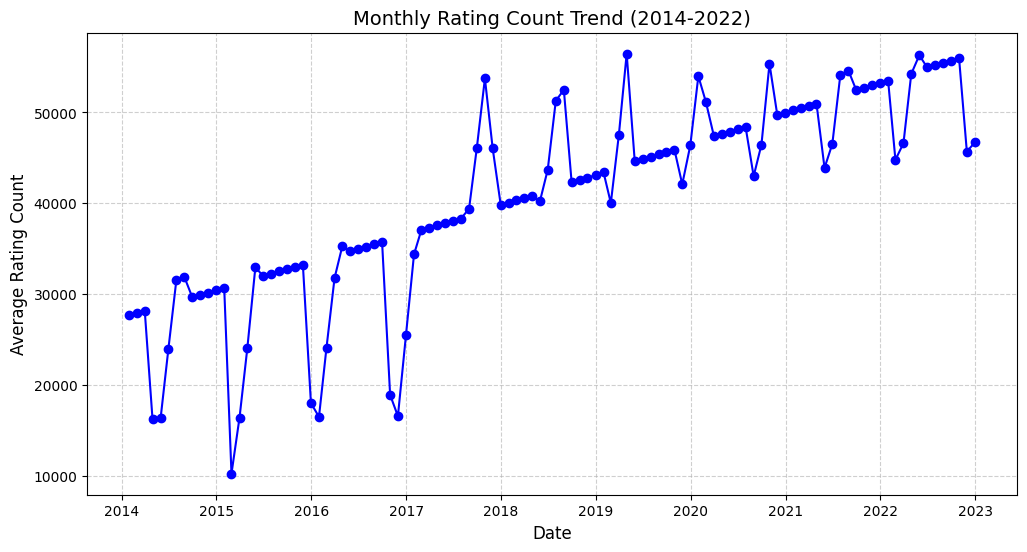

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure 'date' column is in datetime format (with correct day-first format)
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y', errors='coerce')

# Set 'date' as index for resampling
df = df.set_index('date')

# Resample to get monthly averages of rating_count
monthly_rating_counts = df.resample('M').mean()

# Plot the monthly rating count trend
plt.figure(figsize=(12, 6))
plt.plot(monthly_rating_counts.index, monthly_rating_counts['rating_count'], marker='o', linestyle='-', color='blue')

# Title and labels
plt.title("Monthly Rating Count Trend (2014-2022)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Average Rating Count", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.show()








In [59]:
def check_stationarity(timeseries):
    # Perform the Dickey-Fuller test
    result = adfuller(timeseries, autolag='AIC')
    p_value = result[1]
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {p_value}')
    print('Stationary' if p_value < 0.05 else 'Non-Stationary')


check_stationarity(df['rating_count'])


ADF Statistic: -3.213548976124747
p-value: 0.01921368516374073
Stationary


In [60]:
!pip install ace_tools  # Install the 'ace_tools' package


In [61]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

# Ensure 'date' is a datetime index before splitting
df = df.sort_index()

# Split data into train (80%) and test (20%)
split_ratio = 0.8
split_index = int(len(df) * split_ratio)
train, test = df.iloc[:split_index], df.iloc[split_index:]


In [65]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np

# Ensure no NaN values in test and forecasted data
test = test.dropna(subset=['rating_count'])
forecast_values = forecast_values[~pd.Series(forecast_values).isna()]

# Compute metrics
mse = mean_squared_error(test['rating_count'], forecast_values)
rmse = np.sqrt(mse)  # Manually calculate RMSE
mae = mean_absolute_error(test['rating_count'], forecast_values)
mape = mean_absolute_percentage_error(test['rating_count'], forecast_values)

# Print results
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)  # Fixed RMSE computation
print("Mean Absolute Error (MAE):", mae)
print("Mean Absolute Percentage Error (MAPE):", mape)



Mean Squared Error (MSE): 84806987.35457902
Root Mean Squared Error (RMSE): 9209.070927872095
Mean Absolute Error (MAE): 7508.195761693406
Mean Absolute Percentage Error (MAPE): 0.15534793267939487


In [67]:
# Define SARIMA parameters
p, d, q = 1, 1, 1
P, D, Q, s = 1, 1, 1, 12  # Assuming monthly seasonality

# Fit the SARIMA model
model = SARIMAX(df, order=(p, d, q), seasonal_order=(P, D, Q, s))
results = model.fit()
model


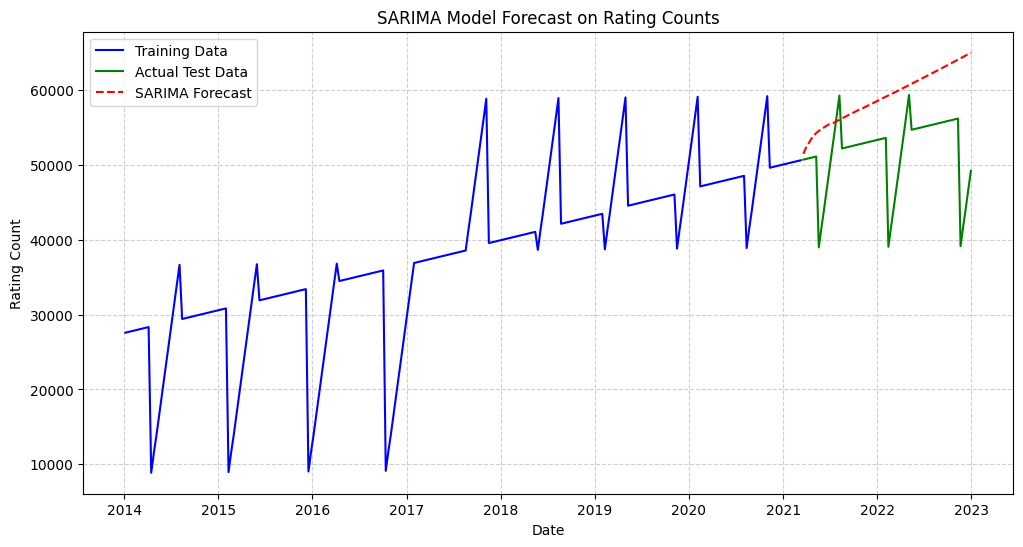

In [66]:
# Fit SARIMA model on training data
sarima_model = sm.tsa.statespace.SARIMAX(
    train['rating_count'],
    order=(3, 0, 4),  # Best (p,d,q) from auto_arima
    seasonal_order=(1, 0, 1, 12),  # Best (P,D,Q,s) from auto_arima
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

# Forecast on test data
forecast_steps = len(test)
forecast = sarima_model.get_forecast(steps=forecast_steps)
forecast_index = test.index  # Align forecast with test data dates
forecast_values = forecast.predicted_mean

# Plot actual vs forecasted values
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['rating_count'], label="Training Data", linestyle="-", color="blue")
plt.plot(test.index, test['rating_count'], label="Actual Test Data", linestyle="-", color="green")
plt.plot(forecast_index, forecast_values, label="SARIMA Forecast", linestyle="--", color="red")

# Titles and labels
plt.title("SARIMA Model Forecast on Rating Counts")
plt.xlabel("Date")
plt.ylabel("Rating Count")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

# Show plot
plt.show()

# Display forecasted values alongside actual test data
forecast_df = pd.DataFrame({'date': forecast_index, 'actual_rating_count': test['rating_count'], 'forecasted_rating_count': forecast_values})